`import matplotlib.pyplot as plt` brings in Python's core plotting library, which most other plotting libraries (including seaborn) draw their charts on top of. `import seaborn as sns` brings in seaborn, a library built on matplotlib that makes it much easier to create nice-looking statistical charts with just one line of code.

**Usecase:** These two imports are needed at the start of the notebook so that every plotting function used later, like `sns.countplot`, `sns.barplot`, and `sns.boxplot`, is available to use.

In [45]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [46]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 

warnings.filterwarnings('ignore') 

# Categorical Data Plots

Now let's discuss using seaborn to plot categorical data! There are a few main plot types for this:

* boxplot
* violinplot
* stripplot
* swarmplot
* barplot
* countplot

Let's go through examples of each!

`sns.load_dataset("tips")` loads a small built-in sample dataset that ships with seaborn, so you don't need to go find and load your own CSV file to practice with. Here it loads the classic "tips" dataset, which has one row per restaurant bill with columns like `total_bill`, `tip`, `sex`, `smoker`, `day`, `time`, and `size`.

**Usecase:** This gives us the actual data used for every categorical plot in this notebook, letting us look at things like how tips or bills change depending on `day`, `sex`, or `smoker` status.

In [47]:
df = sns.load_dataset("tips")
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


`sns.countplot()` simply counts how many rows fall into each category and draws a bar for each count, so it's basically a bar chart of frequencies rather than of some other measured value. Passing a `hue` splits each bar further into smaller bars based on a second category.

**Usecase:** Here it counts how many customers are Male vs Female (`sex`), and within each of those, splits the counts further by whether they were a `smoker` or not, so you can see the raw counts for every combination.

<Axes: xlabel='sex', ylabel='count'>

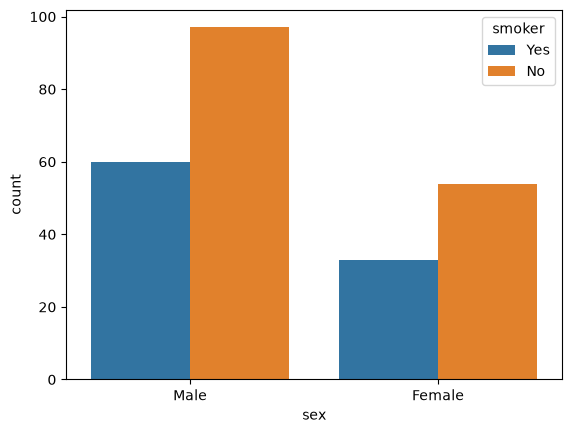

In [48]:
sns.countplot(x = df['sex'],hue = df['smoker'])

`sns.barplot()` draws one bar per category showing an aggregated value of a numeric column for that category (by default the average), along with a small vertical line on top of the bar showing the uncertainty around that value. Unlike `countplot`, which just counts rows, `barplot` summarizes an actual numeric column.

**Usecase:** Here it shows the average `total_bill` for each `sex`, so you can quickly compare whether one group tends to spend more on average than the other.

<Axes: xlabel='sex', ylabel='total_bill'>

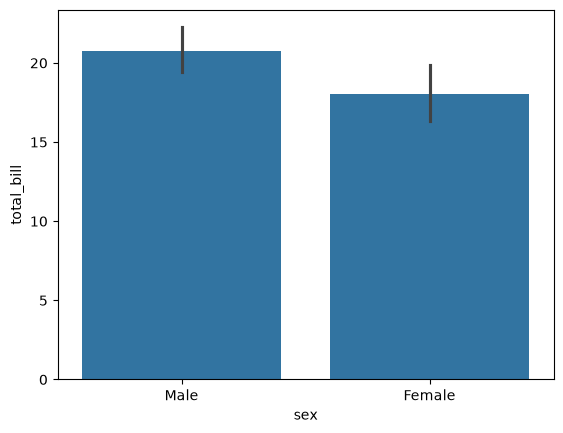

In [49]:
sns.barplot(x = df['sex'],y = df['total_bill'])

You can change the estimator object to your own function, that converts a vector to a scalar
Mean (default): np.mean
Median: np.median
Sum: np.sum
Count: len (to count the number of observations)
Standard Deviation: np.std
Minimum: np.min
Maximum: np.max

<Axes: xlabel='sex', ylabel='tip'>

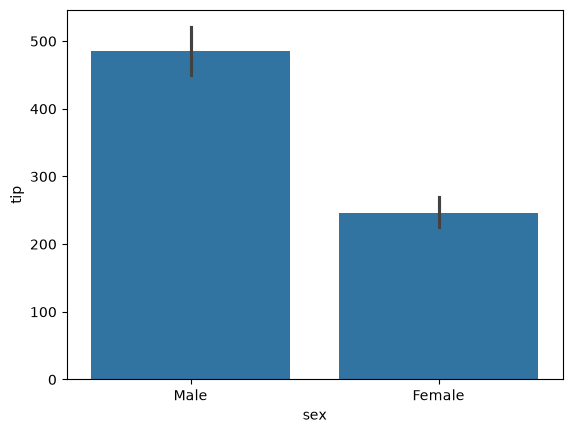

In [50]:
import numpy as np 
sns.barplot(x = df['sex'],y = df['tip'],estimator=np.sum)

<Axes: xlabel='sex', ylabel='total_bill'>

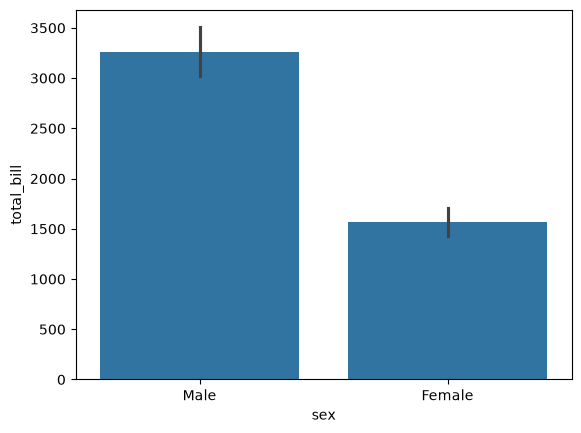

In [51]:
sns.barplot(x = df['sex'],y = df['total_bill'],estimator=np.sum)

`sns.boxplot()` draws a box for each category showing the spread of a numeric column: the middle line is the median, the box covers the middle 50% of the values, the whiskers stretch out to the typical range of the rest, and any dots past that are treated as outliers. The `palette` argument just controls what colors are used for each box.

**Usecase:** Here it shows how `tip` amounts are spread out for each `day` of the week, so you can see not just the typical tip per day but also how much tips vary and whether some days have unusually high or low outlier tips.

<Axes: xlabel='tip', ylabel='day'>

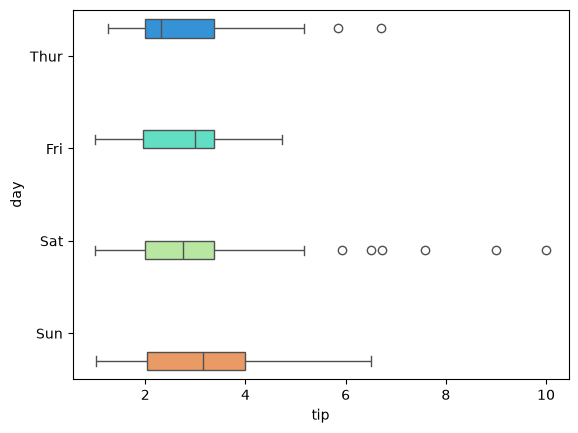

In [52]:
sns.boxplot(x = 'tip', y = 'day', data = df, palette='rainbow', hue = df['day'], legend=False)

<Axes: xlabel='tip', ylabel='day'>

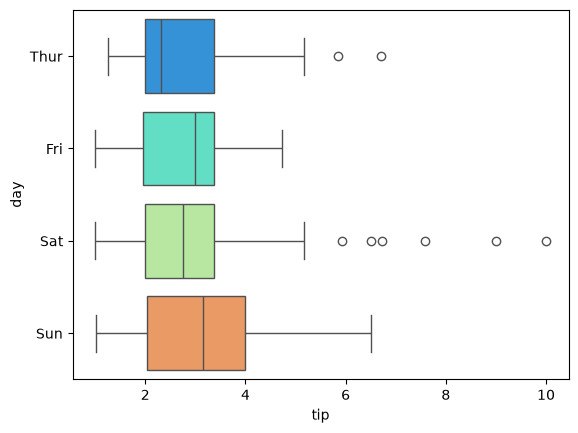

In [53]:
sns.boxplot(x= 'tip',y = 'day',data = df,palette = 'rainbow')

## boxplot and violinplot

boxplots and violinplots are used to shown the distribution of categorical data. A box plot (or box-and-whisker plot) shows the distribution of quantitative data in a way that facilitates comparisons between variables or across levels of a categorical variable. The box shows the quartiles of the dataset while the whiskers extend to show the rest of the distribution, except for points that are determined to be “outliers” using a method that is a function of the inter-quartile range.

<Axes: xlabel='day', ylabel='total_bill'>

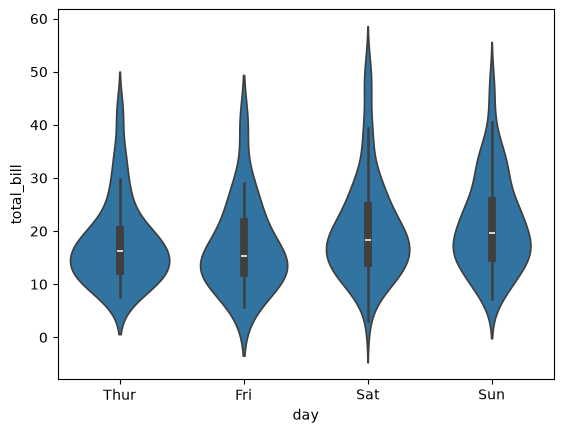

In [54]:
sns.violinplot(x = 'day',y = 'total_bill',data = df)

## stripplot and swarmplot
The stripplot will draw a scatterplot where one variable is categorical. A strip plot can be drawn on its own, but it is also a good complement to a box or violin plot in cases where you want to show all observations along with some representation of the underlying distribution.

The swarmplot is similar to stripplot(), but the points are adjusted (only along the categorical axis) so that they don’t overlap. This gives a better representation of the distribution of values, although it does not scale as well to large numbers of observations (both in terms of the ability to show all the points and in terms of the computation needed to arrange them).

<Axes: xlabel='day', ylabel='total_bill'>

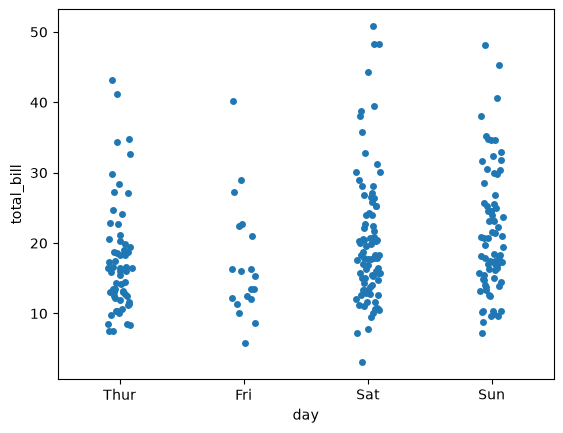

In [55]:
sns.stripplot(x = 'day',y = 'total_bill',data = df)

`sns.swarmplot()` plots every single data point as its own dot along the categorical axis, but nudges overlapping dots sideways so none of them land exactly on top of each other. This means you can see every individual observation, instead of just a summary like a mean or median.

**Usecase:** Here it plots every individual `total_bill` value for each `day`, so rather than hiding the data behind an average, you can see the actual spread and clustering of individual bills on each day.

<Axes: xlabel='day', ylabel='total_bill'>

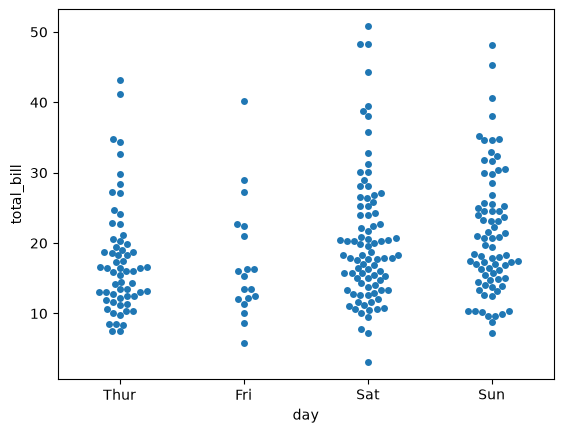

In [56]:
sns.swarmplot(x = 'day',y = 'total_bill',data = df)

This cell draws two plots on top of each other on the same axes. `sns.violinplot()` first draws the smoothed shape of the distribution (like a boxplot, but showing the full shape of the data mirrored on both sides so it looks like a violin), and then `sns.swarmplot()` draws every individual data point as a dot on top of that shape.

**Usecase:** Here it combines both views for `tip` by `day`: the violin shape shows the overall distribution of tips on each day, while the swarm dots layered on top show exactly where the real individual tip values fall within that shape.

<Axes: xlabel='tip', ylabel='day'>

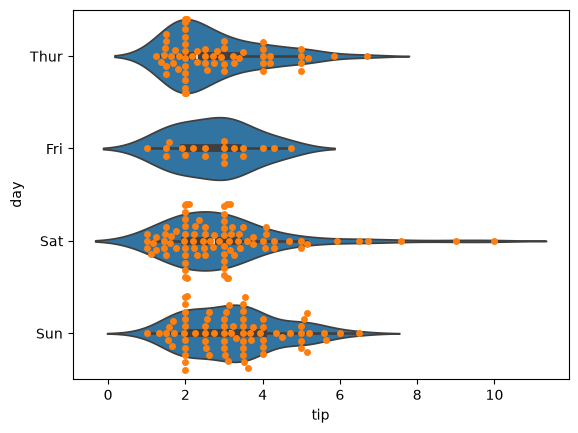

In [57]:
sns.violinplot(x= 'tip',y = 'day',data = df)
sns.swarmplot(x= 'tip',y = 'day',data = df)